
# Compas Analysis

What follows are the calculations performed for ProPublica's analaysis of the COMPAS Recidivism Risk Scores. It might be helpful to open [the methodology](https://www.propublica.org/article/how-we-analyzed-the-compas-recidivism-algorithm/) in another tab to understand the following.

## Loading the Data

We select fields for severity of charge, number of priors, demographics, age, sex, compas scores, and whether each person was accused of a crime within two years.


# Assignment 1

In [1]:

import warnings
warnings.filterwarnings('ignore')


In [2]:

import pandas as pd
import numpy as np
import statsmodels.api as sm
import statsmodels.formula.api as smf
import matplotlib.pyplot as plt

url = "https://raw.githubusercontent.com/propublica/compas-analysis/master/compas-scores-two-years.csv"
raw_data = pd.read_csv(url)
raw_data.shape[0]


7214

In [3]:
raw_data.head(10)

,id,name,first,last,compas_screening_date,sex,dob,age,age_cat,race,...,v_decile_score,v_score_text,v_screening_date,in_custody,out_custody,priors_count.1,start,end,event,two_year_recid
0,1,miguel hernandez,miguel,hernandez,2013-08-14,Male,1947-04-18,69,Greater than 45,Other,...,1,Low,2013-08-14,2014-07-07,2014-07-14,0,0,327,0,0
1,3,kevon dixon,kevon,dixon,2013-01-27,Male,1982-01-22,34,25 - 45,African-American,...,1,Low,2013-01-27,2013-01-26,2013-02-05,0,9,159,1,1
2,4,ed philo,ed,philo,2013-04-14,Male,1991-05-14,24,Less than 25,African-American,...,3,Low,2013-04-14,2013-06-16,2013-06-16,4,0,63,0,1
3,5,marcu brown,marcu,brown,2013-01-13,Male,1993-01-21,23,Less than 25,African-American,...,6,Medium,2013-01-13,NaN,NaN,1,0,1174,0,0
4,6,bouthy pierrelouis,bouthy,pierrelouis,2013-03-26,Male,1973-01-22,43,25 - 45,Other,...,1,Low,2013-03-26,NaN,NaN,2,0,1102,0,0
5,7,marsha miles,marsha,miles,2013-11-30,Male,1971-08-22,44,25 - 45,Other,...,1,Low,2013-11-30,2013-11-30,2013-12-01,0,1,853,0,0
6,8,edward riddle,edward,riddle,2014-02-19,Male,1974-07-23,41,25 - 45,Caucasian,...,2,Low,2014-02-19,2014-03-31,2014-04-18,14,5,40,1,1
7,9,steven stewart,steven,stewart,2013-08-30,Male,1973-02-25,43,25 - 45,Other,...,3,Low,2013-08-30,2014-05-22,2014-06-03,3,0,265,0,0
8,10,elizabeth thieme,elizabeth,thieme,2014-03-16,Female,1976-06-03,39,25 - 45,Caucasian,...,1,Low,2014-03-16,2014-03-15,2014-03-18,0,2,747,0,0
9,13,bo bradac,bo,bradac,2013-11-04,Male,1994-06-10,21,Less than 25,Caucasian,...,5,Medium,2013-11-04,2015-01-06,2015-01-07,1,0,428,1,1



However not all of the rows are useable for the first round of analysis.

There are a number of reasons remove rows because of missing data:
* If the charge date of a defendants Compas scored crime was not within 30 days from when the person was arrested, we assume that because of data quality reasons, that we do not have the right offense.
* We coded the recidivist flag -- `is_recid` -- to be -1 if we could not find a compas case at all.
* In a similar vein, ordinary traffic offenses -- those with a `c_charge_degree` of 'O' -- will not result in Jail time are removed (only two of them).
* We filtered the underlying data from Broward county to include only those rows representing people who had either recidivated in two years, or had at least two years outside of a correctional facility.


In [4]:

numeric_vars = ["age", "priors_count", "days_b_screening_arrest", "decile_score"]
datetime_vars = ["c_jail_in", "c_jail_out"]

cols = [
    "age", "c_charge_degree", "race", "age_cat", "score_text", "sex",
    "priors_count", "days_b_screening_arrest", "decile_score", "is_recid",
    "two_year_recid", "c_jail_in", "c_jail_out"
]

df = raw_data[cols].copy()
df = df[(df["days_b_screening_arrest"].between(-30, 30)) &
        (df["is_recid"] != -1) &
        (df["c_charge_degree"] != "O") &
        (df["score_text"] != "N/A")].copy()

for col in datetime_vars:
    df[col] = pd.to_datetime(df[col], format="%Y-%m-%d %H:%M:%S", errors="coerce", utc=True)

for col in [c for c in df.columns if c not in numeric_vars + datetime_vars]:
    df[col] = df[col].astype("category")

df["crime_factor"] = df["c_charge_degree"].astype("category")
df["age_factor"] = pd.Categorical(df["age_cat"], categories=["25 - 45", "Greater than 45", "Less than 25"])
df["race_factor"] = pd.Categorical(
    df["race"],
    categories=["Caucasian", "African-American", "Asian", "Hispanic", "Native American", "Other"]
)
df["gender_factor"] = pd.Categorical(df["sex"], categories=["Male", "Female"])
df["score_factor"] = pd.Categorical(np.where(df["score_text"] != "Low", "HighScore", "LowScore"), categories=["LowScore", "HighScore"])

df.shape[0]


6172

In [5]:
df.head()

,age,c_charge_degree,race,age_cat,score_text,sex,priors_count,days_b_screening_arrest,decile_score,is_recid,two_year_recid,c_jail_in,c_jail_out,crime_factor,age_factor,race_factor,gender_factor,score_factor
0,69,F,Other,Greater than 45,Low,Male,0,-1.0,1,0,0,2013-08-13 06:03:42+00:00,2013-08-14 05:41:20+00:00,F,Greater than 45,Other,Male,LowScore
1,34,F,African-American,25 - 45,Low,Male,0,-1.0,3,1,1,2013-01-26 03:45:27+00:00,2013-02-05 05:36:53+00:00,F,25 - 45,African-American,Male,LowScore
2,24,F,African-American,Less than 25,Low,Male,4,-1.0,4,1,1,2013-04-13 04:58:34+00:00,2013-04-14 07:02:04+00:00,F,Less than 25,African-American,Male,LowScore
5,44,M,Other,25 - 45,Low,Male,0,0.0,1,0,0,2013-11-30 04:50:18+00:00,2013-12-01 12:28:56+00:00,M,25 - 45,Other,Male,LowScore
6,41,F,Caucasian,25 - 45,Medium,Male,14,-1.0,6,1,1,2014-02-18 05:08:24+00:00,2014-02-24 12:18:30+00:00,F,25 - 45,Caucasian,Male,HighScore


In [6]:

df.info()


<class 'pandas.core.frame.DataFrame'>
Index: 6172 entries, 0 to 7213
Data columns (total 18 columns):
 #   Column                   Non-Null Count  Dtype              
---  ------                   --------------  -----              
 0   age                      6172 non-null   int64              
 1   c_charge_degree          6172 non-null   category           
 2   race                     6172 non-null   category           
 3   age_cat                  6172 non-null   category           
 4   score_text               6172 non-null   category           
 5   sex                      6172 non-null   category           
 6   priors_count             6172 non-null   int64              
 7   days_b_screening_arrest  6172 non-null   float64            
 8   decile_score             6172 non-null   int64              
 9   is_recid                 6172 non-null   category           
 10  two_year_recid           6172 non-null   category           
 11  c_jail_in                6172 non-n

Higher COMPAS scores are slightly correlated with a longer length of stay.

In [7]:

df["length_of_stay"] = (df["c_jail_out"].dt.normalize() - df["c_jail_in"].dt.normalize()).dt.days

df[["length_of_stay", "decile_score"]].corr().loc["length_of_stay", "decile_score"]


np.float64(0.20732969161470416)

After filtering we have the following demographic breakdown:

In [8]:
print(df['age_cat'].value_counts().reindex(['25 - 45', 'Greater than 45', 'Less than 25']))

age_cat
25 - 45            3532
Greater than 45    1293
Less than 25       1347
Name: count, dtype: int64


In [9]:
print(df['race'].value_counts().reindex(['African-American', 'Asian', 'Caucasian', 'Hispanic', 'Native American', 'Other']))

race
African-American    3175
Asian                 31
Caucasian           2103
Hispanic             509
Native American       11
Other                343
Name: count, dtype: int64


In [10]:

print("Black defendants: %.2f%%" % (3175 / 6172 * 100))
print("White defendants: %.2f%%" % (2103 / 6172 * 100))
print("Hispanic defendants: %.2f%%" % (509 / 6172 * 100))
print("Asian defendants: %.2f%%" % (31 / 6172 * 100))
print("Native American defendants: %.2f%%" % (11 / 6172 * 100))


Black defendants: 51.44%
White defendants: 34.07%
Hispanic defendants: 8.25%
Asian defendants: 0.50%
Native American defendants: 0.18%


In [11]:
df['score_text'].value_counts().reindex(['High', 'Low', 'Medium'])

,count
score_text,
High,1144
Low,3421
Medium,1607


In [12]:
pd.crosstab(df['sex'], df['race'])

race,African-American,Asian,Caucasian,Hispanic,Native American,Other
sex,,,,,,
Female,549,2,482,82,2,58
Male,2626,29,1621,427,9,285


In [13]:
df['sex'].value_counts().reindex(['Female', 'Male'])

,count
sex,
Female,1175
Male,4997


In [14]:

print("Men: %.2f%%" % (4997 / 6172 * 100))
print("Women: %.2f%%" % (1175 / 6172 * 100))


Men: 80.96%
Women: 19.04%


In [15]:
df.query('two_year_recid == 1').shape[0]

2809

In [16]:
df.query('two_year_recid == 1').shape[0] / df.shape[0] * 100

45.51198963058976


Judges are often presented with two sets of scores from the Compas system -- one that classifies people into High, Medium and Low risk, and a corresponding decile score. There is a clear downward trend in the decile scores as those scores increase for white defendants.


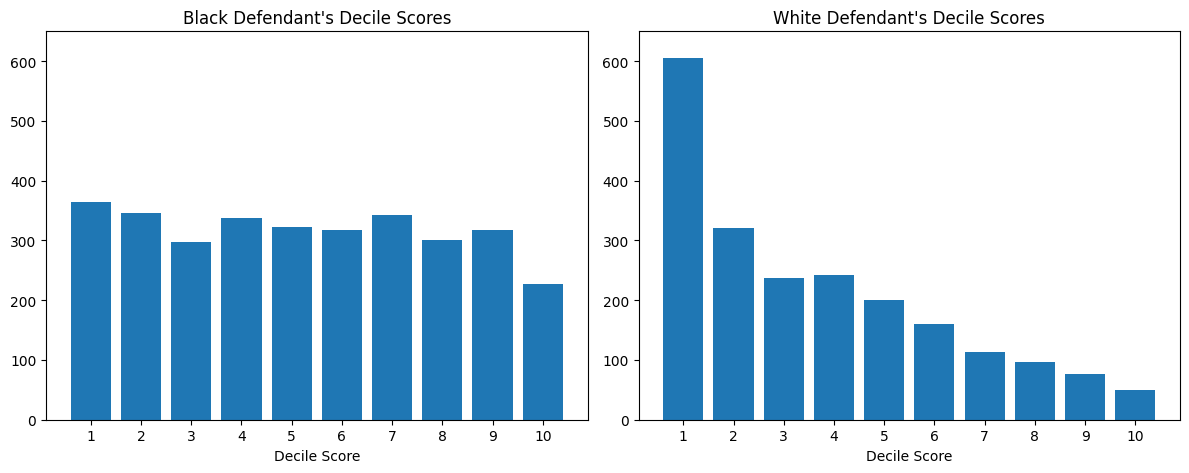

In [17]:

black_counts = df.loc[df["race"] == "African-American", "decile_score"].value_counts().sort_index()
white_counts = df.loc[df["race"] == "Caucasian", "decile_score"].value_counts().sort_index()

fig, axes = plt.subplots(1, 2, figsize=(12, 4.84))
axes[0].bar(black_counts.index.astype(str), black_counts.values)
axes[0].set_xlabel("Decile Score")
axes[0].set_ylim(0, 650)
axes[0].set_title("Black Defendant's Decile Scores")

axes[1].bar(white_counts.index.astype(str), white_counts.values)
axes[1].set_xlabel("Decile Score")
axes[1].set_ylim(0, 650)
axes[1].set_title("White Defendant's Decile Scores")

plt.tight_layout()
plt.show()


In [18]:
pd.crosstab(df['decile_score'], df['race'])

race,African-American,Asian,Caucasian,Hispanic,Native American,Other
decile_score,,,,,,
1,365,15,605,159,0,142
2,346,4,321,89,2,60
3,298,5,238,73,1,32
4,337,0,243,47,0,39
5,323,1,200,39,0,19
6,318,2,160,27,2,20
7,343,1,113,28,2,9
8,301,2,96,14,0,7
9,317,0,77,17,2,7



## Racial Bias in Compas

After filtering out bad rows, our first question is whether there is a significant difference in Compas scores between races. To do so we need to change some variables into factors, and run a logistic regression, comparing low scores to high scores.


In [19]:

model_glm = smf.glm(
    formula='score_binary ~ C(gender_factor, Treatment(reference="Male")) + C(age_factor, Treatment(reference="25 - 45")) + C(race_factor, Treatment(reference="Caucasian")) + priors_count + C(crime_factor) + two_year_recid',
    data=df.assign(score_binary=(df["score_factor"] == "HighScore").astype(int)),
    family=sm.families.Binomial()
).fit()

model_glm.summary()


<class 'statsmodels.iolib.summary.Summary'>
"""
                 Generalized Linear Model Regression Results                  
==============================================================================
Dep. Variable:           score_binary   No. Observations:                 6172
Model:                            GLM   Df Residuals:                     6160
Model Family:                Binomial   Df Model:                           11
Link Function:                  Logit   Scale:                          1.0000
Method:                          IRLS   Log-Likelihood:                -3084.2
Date:                Sun, 05 Apr 2026   Deviance:                       6168.4
Time:                        20:28:29   Pearson chi2:                 6.07e+03
No. Iterations:                     6   Pseudo R-squ. (CS):             0.3128
Covariance Type:            nonrobust                                         
========================================================================================================================================
                                                                           coef    std err          z      P>|z|      [0.025      0.975]
----------------------------------------------------------------------------------------------------------------------------------------
Intercept                                                               -1.5255      0.079    -19.430      0.000      -1.679      -1.372
C(gender_factor, Treatment(reference="Male"))[T.Female]                  0.2213      0.080      2.783      0.005       0.065       0.377
C(age_factor, Treatment(reference="25 - 45"))[T.Greater than 45]        -1.3556      0.099    -13.682      0.000      -1.550      -1.161
C(age_factor, Treatment(reference="25 - 45"))[T.Less than 25]            1.3084      0.076     17.232      0.000       1.160       1.457
C(race_factor, Treatment(reference="Caucasian"))[T.African-American]     0.4772      0.069      6.881      0.000       0.341       0.613
C(race_factor, Treatment(reference="Caucasian"))[T.Asian]               -0.2544      0.478     -0.532      0.595      -1.192       0.683
C(race_factor, Treatment(reference="Caucasian"))[T.Hispanic]            -0.4284      0.128     -3.344      0.001      -0.680      -0.177
C(race_factor, Treatment(reference="Caucasian"))[T.Native American]      1.3942      0.766      1.820      0.069      -0.107       2.896
C(race_factor, Treatment(reference="Caucasian"))[T.Other]               -0.8263      0.162     -5.098      0.000      -1.144      -0.509
C(crime_factor)[T.M]                                                    -0.3112      0.067     -4.677      0.000      -0.442      -0.181
two_year_recid[T.1]                                                      0.6859      0.064     10.713      0.000       0.560       0.811
priors_count                                                             0.2689      0.011     24.221      0.000       0.247       0.291
========================================================================================================================================
"""

Black defendants are 45% more likely than white defendants to receive a higher score correcting for the seriousness of their crime, previous arrests, and future criminal behavior.

In [20]:

control = np.exp(model_glm.params["Intercept"]) / (1 + np.exp(model_glm.params["Intercept"]))
race_coef = model_glm.params['C(race_factor, Treatment(reference="Caucasian"))[T.African-American]']
np.exp(race_coef) / (1 - control + (control * np.exp(race_coef)))


np.float64(1.4528374133823474)

Women are 19.4% more likely than men to get a higher score.

In [21]:

gender_coef = model_glm.params['C(gender_factor, Treatment(reference="Male"))[T.Female]']
np.exp(gender_coef) / (1 - control + (control * np.exp(gender_coef)))


np.float64(1.194794653883454)

Most surprisingly, people under 25 are 2.5 times as likely to get a higher score as middle aged defendants.

In [22]:

age_coef = model_glm.params['C(age_factor, Treatment(reference="25 - 45"))[T.Less than 25]']
np.exp(age_coef) / (1 - control + (control * np.exp(age_coef)))


np.float64(2.496119530753958)

In [23]:

df["pred_prob"] = model_glm.predict(df)
df["pred_class"] = pd.Categorical(
    np.where(df["pred_prob"] >= 0.5, "Recid", "No Recid"),
    categories=["No Recid", "Recid"]
)


In [24]:

print("\nOverall Confusion Matrix")

overall_cm = pd.crosstab(df["pred_class"], df["two_year_recid"], rownames=["Predicted"], colnames=["Actual"])
print(overall_cm)

TP = overall_cm.loc["Recid", 1]
TN = overall_cm.loc["No Recid", 0]
FP = overall_cm.loc["Recid", 0]
FN = overall_cm.loc["No Recid", 1]
n = overall_cm.to_numpy().sum()

print("Accuracy  : %.3f" % ((TP + TN) / n))
print("Precision : %.3f" % (TP / (TP + FP)))
print("Recall    : %.3f" % (TP / (TP + FN)))
print("FPR       : %.3f" % (FP / (FP + TN)))
print("FNR       : %.3f" % (FN / (FN + TP)))



Overall Confusion Matrix
Actual        0     1
Predicted            
No Recid   2653   945
Recid       710  1864
Accuracy  : 0.732
Precision : 0.724
Recall    : 0.664
FPR       : 0.211
FNR       : 0.336


In [25]:

print("Confusion Matrix by Race")

race_metrics = (
    df.assign(
        actual=df["two_year_recid"].astype(int),
        pred=(df["pred_class"] == "Recid").astype(int)
    )
    .groupby("race")
    .apply(lambda g: pd.Series({
        "n": len(g),
        "TP": ((g["pred"] == 1) & (g["actual"] == 1)).sum(),
        "TN": ((g["pred"] == 0) & (g["actual"] == 0)).sum(),
        "FP": ((g["pred"] == 1) & (g["actual"] == 0)).sum(),
        "FN": ((g["pred"] == 0) & (g["actual"] == 1)).sum(),
    }))
    .reset_index()
)

race_metrics["Accuracy"] = ((race_metrics["TP"] + race_metrics["TN"]) / race_metrics["n"]).round(3)
race_metrics["Precision"] = (race_metrics["TP"] / (race_metrics["TP"] + race_metrics["FP"])).round(3)
race_metrics["Recall"] = (race_metrics["TP"] / (race_metrics["TP"] + race_metrics["FN"])).round(3)
race_metrics["FPR"] = (race_metrics["FP"] / (race_metrics["FP"] + race_metrics["TN"])).round(3)
race_metrics["FNR"] = (race_metrics["FN"] / (race_metrics["FN"] + race_metrics["TP"])).round(3)
race_metrics = race_metrics.sort_values("n", ascending=False)

print(race_metrics)


Confusion Matrix by Race
               race     n    TP    TN   FP   FN  Accuracy  Precision  Recall  \
0  African-American  3175  1373   959  555  288     0.734      0.712   0.827   
2         Caucasian  2103   381  1148  133  441     0.727      0.741   0.464   
3          Hispanic   509    81   306   14  108     0.760      0.853   0.429   
5             Other   343    22   216    3  102     0.694      0.880   0.177   
1             Asian    31     2    22    1    6     0.774      0.667   0.250   
4   Native American    11     5     2    4    0     0.636      0.556   1.000   

     FPR    FNR  
0  0.367  0.173  
2  0.104  0.536  
3  0.044  0.571  
5  0.014  0.823  
1  0.043  0.750  
4  0.667  0.000  


In [26]:

print("FPR and FNR Disparity by Race")

white_fpr = race_metrics.loc[race_metrics["race"] == "Caucasian", "FPR"].iloc[0]
white_fnr = race_metrics.loc[race_metrics["race"] == "Caucasian", "FNR"].iloc[0]

disparity = race_metrics[["race", "n", "FPR", "FNR"]].copy()
disparity["delta_FPR"] = (disparity["FPR"] - white_fpr).round(3)
disparity["delta_FNR"] = (disparity["FNR"] - white_fnr).round(3)

print(disparity)


FPR and FNR Disparity by Race
               race     n    FPR    FNR  delta_FPR  delta_FNR
0  African-American  3175  0.367  0.173      0.263     -0.363
2         Caucasian  2103  0.104  0.536      0.000      0.000
3          Hispanic   509  0.044  0.571     -0.060      0.035
5             Other   343  0.014  0.823     -0.090      0.287
1             Asian    31  0.043  0.750     -0.061      0.214
4   Native American    11  0.667  0.000      0.563     -0.536


## Assignment 2


In [27]:
%pip -q install shap lime dice-ml


     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 275.7/275.7 kB 3.8 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.5/2.5 MB 31.2 MB/s eta 0:00:00


In [28]:
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.metrics import accuracy_score, roc_auc_score, confusion_matrix
import shap
from lime.lime_tabular import LimeTabularExplainer
import dice_ml
from dice_ml import Dice


In [29]:
numeric_features = ["age", "priors_count", "days_b_screening_arrest", "decile_score"]
category_features = ["c_charge_degree", "race", "age_cat", "score_text", "sex"]
features = numeric_features + category_features
target = "two_year_recid"

X = df[features].copy()
y = df[target].astype(int).copy()

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

preprocessor = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), numeric_features),
        ("cat", OneHotEncoder(handle_unknown="ignore", sparse_output=False), category_features),
    ]
)

lr_pipeline = Pipeline([
    ("preprocessor", preprocessor),
    ("classifier", LogisticRegression(max_iter=1000, random_state=42))
])

gbt_pipeline = Pipeline([
    ("preprocessor", preprocessor),
    ("classifier", GradientBoostingClassifier(n_estimators=200, max_depth=4, random_state=42))
])

lr_pipeline.fit(X_train, y_train)
gbt_pipeline.fit(X_train, y_train)

print("Logistic Regression")
print("Accuracy:", round(accuracy_score(y_test, lr_pipeline.predict(X_test)), 3))
print("AUC:", round(roc_auc_score(y_test, lr_pipeline.predict_proba(X_test)[:, 1]), 3))

print("\nGradient-Boosted Tree")
print("Accuracy:", round(accuracy_score(y_test, gbt_pipeline.predict(X_test)), 3))
print("AUC:", round(roc_auc_score(y_test, gbt_pipeline.predict_proba(X_test)[:, 1]), 3))


Logistic Regression
Accuracy: 0.693
AUC: 0.74

Gradient-Boosted Tree
Accuracy: 0.697
AUC: 0.74


In [30]:
fitted_preprocessor = gbt_pipeline.named_steps["preprocessor"]
gbt_model = gbt_pipeline.named_steps["classifier"]

X_train_enc = fitted_preprocessor.transform(X_train)
X_test_enc = fitted_preprocessor.transform(X_test)

feature_names = numeric_features + list(
    fitted_preprocessor.named_transformers_["cat"].get_feature_names_out(category_features)
)

X_train_enc_df = pd.DataFrame(X_train_enc, columns=feature_names, index=X_train.index)
X_test_enc_df = pd.DataFrame(X_test_enc, columns=feature_names, index=X_test.index)

test_scores = X_test.copy()
test_scores["pred_prob"] = gbt_pipeline.predict_proba(X_test)[:, 1]

black_high_idx = test_scores.loc[test_scores["race"] == "African-American", "pred_prob"].idxmax()
black_low_idx = test_scores.loc[test_scores["race"] == "African-American", "pred_prob"].idxmin()
white_high_idx = test_scores.loc[test_scores["race"] == "Caucasian", "pred_prob"].idxmax()
white_low_idx = test_scores.loc[test_scores["race"] == "Caucasian", "pred_prob"].idxmin()

selected_cases = {
    "Black Highest Risk": black_high_idx,
    "Black Lowest Risk": black_low_idx,
    "White Highest Risk": white_high_idx,
    "White Lowest Risk": white_low_idx,
}

pd.DataFrame({
    "case": list(selected_cases.keys()),
    "index": list(selected_cases.values()),
    "pred_prob": [test_scores.loc[idx, "pred_prob"] for idx in selected_cases.values()]
})


,case,index,pred_prob
0,Black Highest Risk,6293,0.996793
1,Black Lowest Risk,4051,0.027024
2,White Highest Risk,4413,0.993741
3,White Lowest Risk,3093,0.018984


### SHAP


 97%|=================== | 1198/1235 [00:14<00:00]       

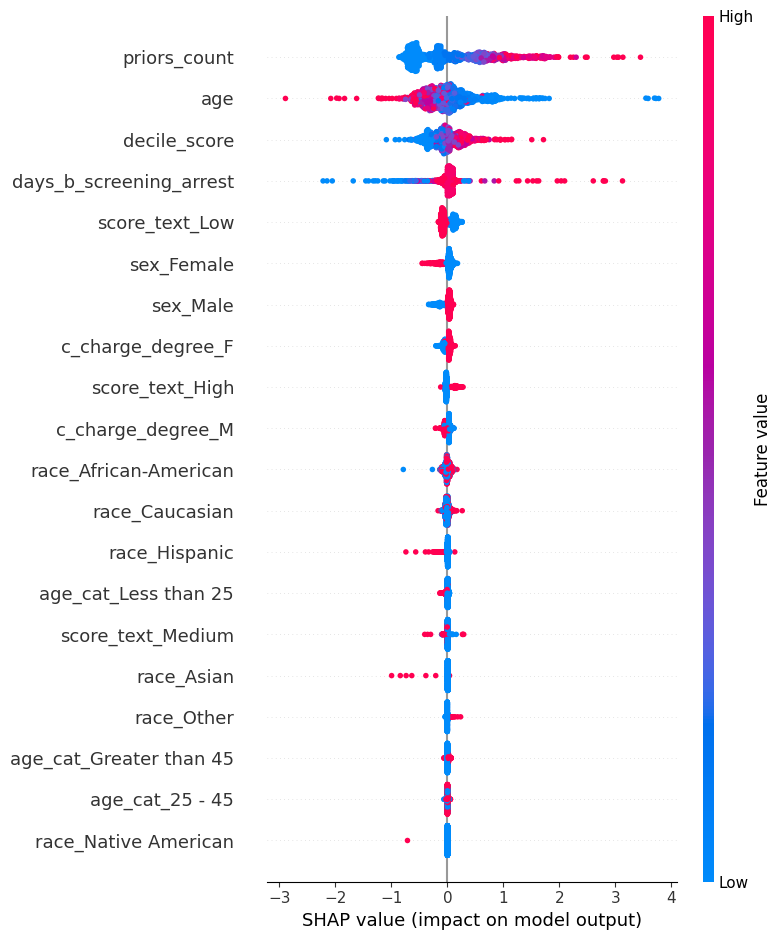

In [31]:
explainer_shap = shap.Explainer(gbt_model, X_train_enc_df)
shap_values = explainer_shap(X_test_enc_df, check_additivity=False)

shap.summary_plot(shap_values.values, X_test_enc_df, feature_names=feature_names)

Black Highest Risk - Predicted probability: 0.997


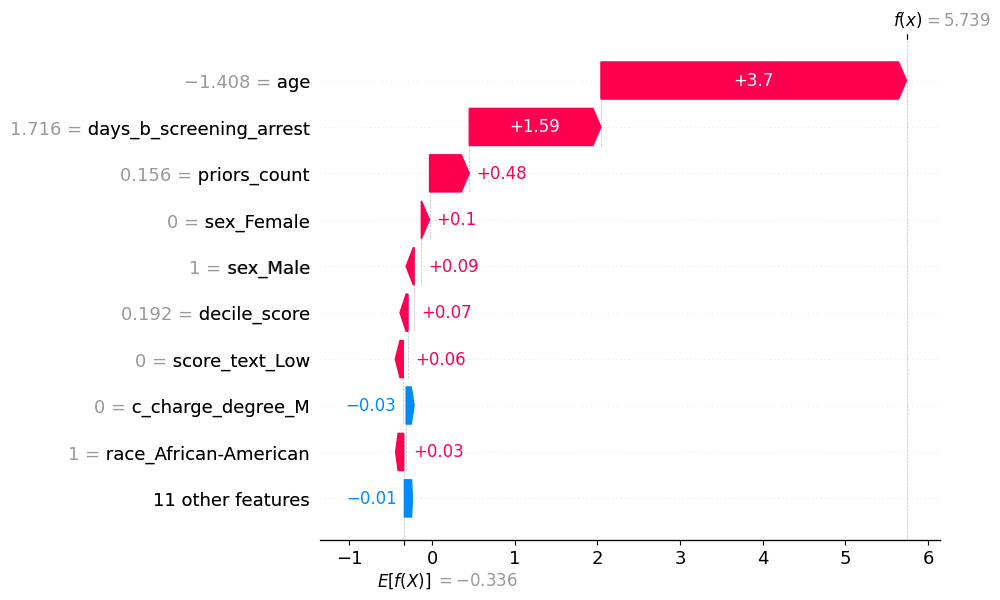

Black Lowest Risk - Predicted probability: 0.027


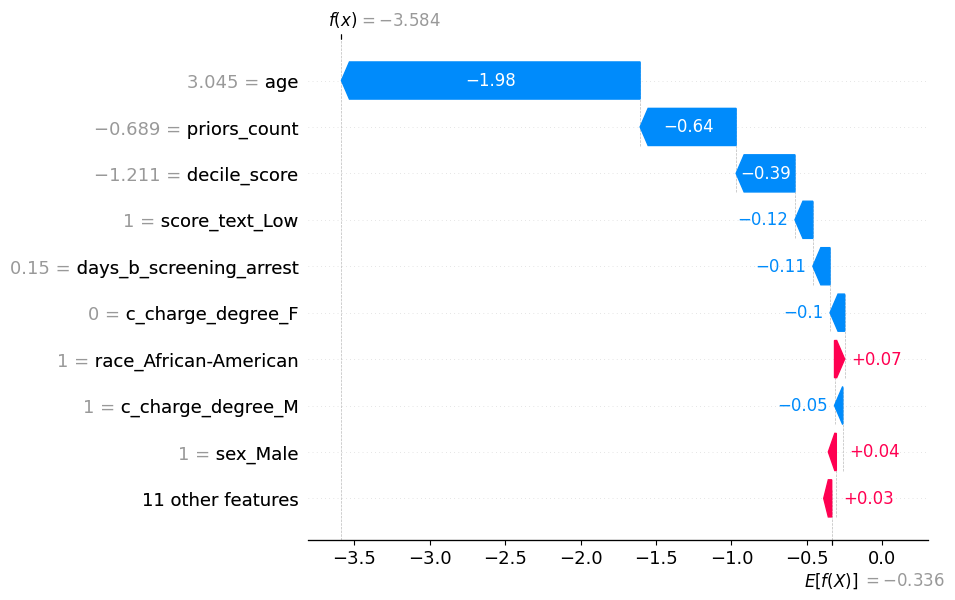

White Highest Risk - Predicted probability: 0.994


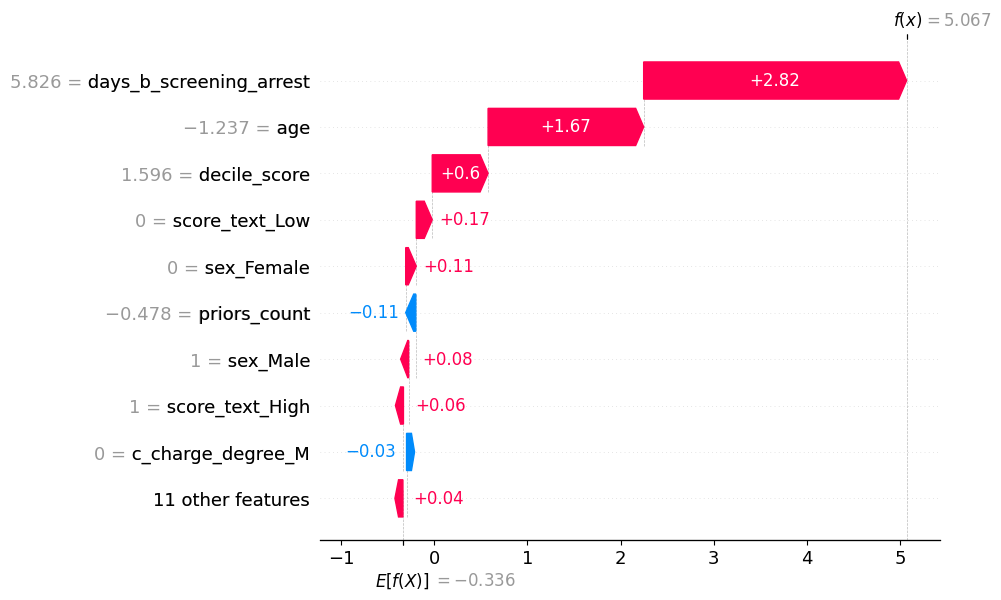

White Lowest Risk - Predicted probability: 0.019


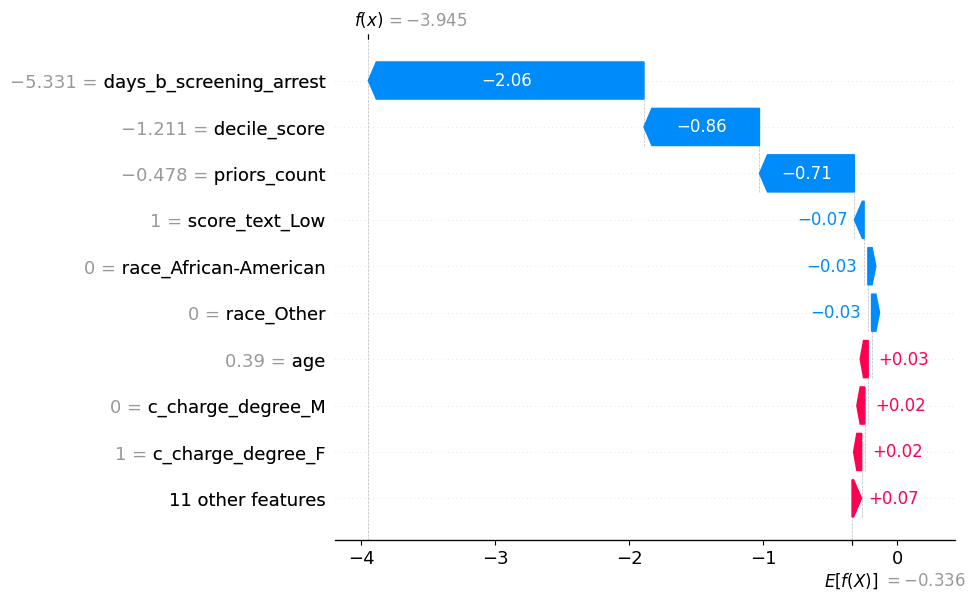

In [32]:
for label, idx in selected_cases.items():
    print(label, "-", "Predicted probability:", round(float(test_scores.loc[idx, "pred_prob"]), 3))
    shap.plots.waterfall(shap_values[X_test_enc_df.index.get_loc(idx)], max_display=10)


### LIME


In [33]:
lime_explainer = LimeTabularExplainer(
    training_data=X_train_enc_df.to_numpy(),
    feature_names=feature_names,
    class_names=["No Recid", "Recid"],
    mode="classification",
    discretize_continuous=True,
    random_state=42
)

lime_results = {}

for label, idx in selected_cases.items():
    exp = lime_explainer.explain_instance(
        data_row=X_test_enc_df.loc[idx].to_numpy(),
        predict_fn=gbt_model.predict_proba,
        num_features=10
    )
    lime_results[label] = pd.DataFrame(exp.as_list(), columns=["feature", "lime_weight"])
    print(label)
    print(lime_results[label])
    print()


Black Highest Risk
                            feature  lime_weight
0    days_b_screening_arrest > 0.15     0.338419
1                      age <= -0.81     0.142664
2                race_Asian <= 0.00     0.094203
3      race_Native American <= 0.00     0.080203
4            score_text_Low <= 0.00     0.046338
5             race_Hispanic <= 0.00     0.045432
6                sex_Female <= 0.00     0.042956
7      -0.48 < priors_count <= 0.16    -0.038423
8           score_text_High <= 0.00    -0.024791
9  0.00 < score_text_Medium <= 1.00    -0.020639

Black Lowest Risk
                           feature  lime_weight
0  days_b_screening_arrest <= 0.15    -0.344391
1                       age > 0.56    -0.116940
2               race_Asian <= 0.00     0.099001
3    0.00 < score_text_Low <= 1.00    -0.059790
4               sex_Female <= 0.00     0.050593
5            priors_count <= -0.69    -0.047093
6            decile_score <= -0.86    -0.038473
7     race_Native American <= 0.00     

In [34]:
shap_results = {}

for label, idx in selected_cases.items():
    loc = X_test_enc_df.index.get_loc(idx)
    shap_case = pd.DataFrame({
        "feature": feature_names,
        "shap_value": shap_values.values[loc]
    })
    shap_case["abs_shap"] = shap_case["shap_value"].abs()
    shap_results[label] = shap_case.sort_values("abs_shap", ascending=False).head(10)[["feature", "shap_value"]]

    print(label)
    print(shap_results[label])
    print()


Black Highest Risk
                    feature  shap_value
0                       age    3.696920
2   days_b_screening_arrest    1.593108
1              priors_count    0.480664
18               sex_Female    0.099432
19                 sex_Male    0.087047
3              decile_score    0.073699
16           score_text_Low    0.057589
5         c_charge_degree_M   -0.034577
6     race_African-American    0.030416
9             race_Hispanic    0.023811

Black Lowest Risk
                    feature  shap_value
0                       age   -1.978551
1              priors_count   -0.635884
3              decile_score   -0.389751
16           score_text_Low   -0.118540
2   days_b_screening_arrest   -0.113850
4         c_charge_degree_F   -0.096974
6     race_African-American    0.067404
5         c_charge_degree_M   -0.054879
19                 sex_Male    0.042805
18               sex_Female    0.037766

White Highest Risk
                    feature  shap_value
2   days_b_screening_a

In [35]:
comparison_results = {}

for label in selected_cases:
    lime_top = lime_results[label].copy()
    lime_top["normalized_feature"] = lime_top["feature"].str.extract(r"([A-Za-z_][A-Za-z0-9_]*(?:\[[^\]]+\])?)")[0]

    shap_top = shap_results[label].copy()
    shap_top["normalized_feature"] = shap_top["feature"]

    overlap = sorted(set(lime_top["normalized_feature"].dropna()) & set(shap_top["normalized_feature"].dropna()))
    lime_only = sorted(set(lime_top["normalized_feature"].dropna()) - set(shap_top["normalized_feature"].dropna()))
    shap_only = sorted(set(shap_top["normalized_feature"].dropna()) - set(lime_top["normalized_feature"].dropna()))

    comparison_results[label] = {
        "overlap": overlap,
        "lime_only": lime_only,
        "shap_only": shap_only
    }

comparison_results


{'Black Highest Risk': {'overlap': ['age',
   'days_b_screening_arrest',
   'priors_count',
   'race_Hispanic',
   'score_text_Low',
   'sex_Female'],
  'lime_only': ['race_Asian',
   'race_Native',
   'score_text_High',
   'score_text_Medium'],
  'shap_only': ['c_charge_degree_M',
   'decile_score',
   'race_African-American',
   'sex_Male']},
 'Black Lowest Risk': {'overlap': ['age',
   'days_b_screening_arrest',
   'decile_score',
   'priors_count',
   'score_text_Low',
   'sex_Female'],
  'lime_only': ['race_Asian',
   'race_Hispanic',
   'race_Native',
   'score_text_High'],
  'shap_only': ['c_charge_degree_F',
   'c_charge_degree_M',
   'race_African-American',
   'sex_Male']},
 'White Highest Risk': {'overlap': ['age',
   'days_b_screening_arrest',
   'decile_score',
   'priors_count',
   'score_text_High',
   'score_text_Low',
   'sex_Female'],
  'lime_only': ['race_Asian', 'race_Hispanic', 'race_Native'],
  'shap_only': ['c_charge_degree_M', 'race_Caucasian', 'sex_Male']},
 'W

### LIME and SHAP Comparison

Across the four individuals, LIME and SHAP should be read as complementary rather than interchangeable. They usually agree on the dominant drivers when a prediction is strongly influenced by a small set of variables, but they may differ in feature ranking, magnitude, or whether a variable appears at all. LIME is a local surrogate fit around one point, while SHAP allocates the prediction gap across all encoded features. When they diverge, the practical implication is that explanation results are method-dependent. For governance, a single explanation method should not be treated as conclusive evidence about fairness or model logic. Divergence should trigger additional review, stability checks, and subgroup monitoring rather than overconfidence in one plot.


### Counterfactuals


In [36]:
dice_data = dice_ml.Data(
    dataframe=pd.concat([X_train.reset_index(drop=True), y_train.reset_index(drop=True).rename(target)], axis=1),
    continuous_features=numeric_features,
    outcome_name=target
)

dice_model = dice_ml.Model(
    model=gbt_pipeline,
    backend="sklearn",
    model_type="classifier"
)

exp_dice = Dice(dice_data, dice_model, method="random")


In [37]:
counterfactual_summaries = []

for label, idx in selected_cases.items():
    query = X_test.loc[[idx]].copy()

    cf = exp_dice.generate_counterfactuals(
        query_instances=query,
        total_CFs=1,
        desired_class="opposite",
        features_to_vary=features,
        permitted_range={
            "age": [int(df["age"].min()), int(df["age"].max())],
            "priors_count": [int(df["priors_count"].min()), int(df["priors_count"].max())],
            "days_b_screening_arrest": [int(df["days_b_screening_arrest"].min()), int(df["days_b_screening_arrest"].max())],
            "decile_score": [int(df["decile_score"].min()), int(df["decile_score"].max())],
        }
    )

    cf_df = cf.cf_examples_list[0].final_cfs_df.copy()
    print(label)
    if cf_df.empty:
        print("No counterfactual found")
        print()
        continue

    display(cf_df)

    original_row = query.iloc[0]
    cf_row = cf_df.iloc[0][features]
    changed_features = [col for col in features if str(original_row[col]) != str(cf_row[col])]
    immutable_changes = [col for col in ["race", "sex"] if col in changed_features]

    counterfactual_summaries.append({
        "case": label,
        "index": idx,
        "original_prediction": gbt_pipeline.predict(query)[0],
        "counterfactual_prediction": cf_df.iloc[0][target],
        "changed_features": changed_features,
        "immutable_changes": immutable_changes
    })

    print("Changed features:", changed_features)
    print("Immutable feature changes:", immutable_changes if immutable_changes else "None")
    print()


100%|██████████| 1/1 [00:00<00:00,  2.04it/s]

Black Highest Risk


,age,priors_count,days_b_screening_arrest,decile_score,c_charge_degree,race,age_cat,score_text,sex,two_year_recid
0,33,4,7.0,5,F,African-American,Less than 25,Medium,Female,0


Changed features: ['age', 'sex']
Immutable feature changes: ['sex']



100%|██████████| 1/1 [00:00<00:00,  5.01it/s]

...

Changed features: ['age', 'age_cat']
Immutable feature changes: None



100%|██████████| 1/1 [00:00<00:00,  2.52it/s]

White Lowest Risk


,age,priors_count,days_b_screening_arrest,decile_score,c_charge_degree,race,age_cat,score_text,sex,two_year_recid
0,39,1,9.1,1,F,Caucasian,25 - 45,Low,Male,1


Changed features: ['days_b_screening_arrest']
Immutable feature changes: None



In [38]:
counterfactual_summary_df = pd.DataFrame(counterfactual_summaries)
counterfactual_summary_df


,case,index,original_prediction,counterfactual_prediction,changed_features,immutable_changes
0,Black Highest Risk,6293,1,0,"[age, sex]",[sex]
1,Black Lowest Risk,4051,0,1,"[age, days_b_screening_arrest]",[]
2,White Highest Risk,4413,1,0,"[age, age_cat]",[]
3,White Lowest Risk,3093,0,1,[days_b_screening_arrest],[]


### Governance Memo

To: Court Auditor

The explanation analysis of the COMPAS replacement model suggests that predictions are driven primarily by priors_count, age, decile_score, and days_b_screening_arrest. The SHAP summary plot showed that higher prior counts, higher decile scores, and larger values of days_b_screening_arrest generally increased the predicted risk score, while older age generally lowered predicted risk. Race-related variables appeared much lower in the importance ranking and had relatively small direct contributions compared to the core behavioral and score-based features.

For the highest-risk Black defendant, the strongest drivers were young age and a high value of days_b_screening_arrest, followed by prior count and decile score. For the lowest-risk Black defendant, older age, lower prior count, lower decile score, and lower days_b_screening_arrest reduced the predicted risk substantially. Similar patterns appeared for White defendants. The highest-risk White defendant was driven mainly by days_b_screening_arrest, younger age, and higher decile score, while the lowest-risk White defendant had low days_b_screening_arrest, low prior count, and low decile score.

The explanation methods suggest that the model relies more on criminal history and timing-related variables than on direct race indicators. However, this should not be interpreted as proof that the model is fair. Even if race variables have small direct effects, other features may still act as proxies for race because of unequal distributions across groups. The decile score distributions already show that Black defendants are more concentrated in higher score categories than White defendants.

These results suggest that the model should be monitored beyond overall accuracy. Recommended governance steps include reviewing false positive rates across racial groups, monitoring the stability of SHAP and LIME explanations over time, checking for proxy discrimination through correlated variables, and requiring periodic human review of high-risk cases before decisions are finalized.


# Assignment 3

In [39]:
import importlib
import subprocess
import sys

def _try_install_and_import():
    package_attempts = [
        ["solas-ai"],
        ["git+https://github.com/SolasAI/solas-ai-disparity.git"],
    ]
    for pkg in package_attempts:
        try:
            subprocess.run([sys.executable, "-m", "pip", "install", "-q", *pkg], check=True)
            return importlib.import_module("solas_disparity")
        except Exception:
            pass
    try:
        return importlib.import_module("solas_disparity")
    except Exception:
        return None

sd = _try_install_and_import()

if sd is None:
    print("solas_disparity could not be imported. Manual calculations will still run.")
else:
    print("solas_disparity imported successfully.")

solas_disparity imported successfully.


In [40]:
from statsmodels.stats.proportion import proportions_ztest

audit_df = X_test.copy()
audit_df[target] = y_test.astype(int)
audit_df["pred"] = gbt_pipeline.predict(X_test).astype(int)
audit_df["score"] = gbt_pipeline.predict_proba(X_test)[:, 1]

# favorable outcome for AIR / ME
audit_df["selected"] = 1 - audit_df["pred"]

audit_df["race_sex"] = audit_df["race"].astype(str) + " | " + audit_df["sex"].astype(str)

audit_df.head()

,age,priors_count,days_b_screening_arrest,decile_score,c_charge_degree,race,age_cat,score_text,sex,two_year_recid,pred,score,selected,race_sex
6019,21,4,-1.0,10,F,Hispanic,Less than 25,High,Male,1,1,0.521611,0,Hispanic | Male
2839,50,5,29.0,2,F,African-American,Greater than 45,Low,Male,0,1,0.881942,0,African-American | Male
2808,24,2,-1.0,10,F,Other,Less than 25,High,Male,1,1,0.687883,0,Other | Male
5770,52,0,-1.0,1,F,Asian,Greater than 45,Low,Male,0,0,0.333420,1,Asian | Male
1885,35,7,-23.0,4,F,African-American,25 - 45,Low,Male,1,1,0.504862,0,African-American | Male


In [41]:
def manual_air_me(df, group_col, reference_group, favorable_col="selected"):
    rows = []
    ref_rate = df.loc[df[group_col] == reference_group, favorable_col].mean()

    for group, g in df.groupby(group_col):
        rate = g[favorable_col].mean()
        rows.append({
            "group": group,
            "n": len(g),
            "selection_rate": rate,
            "AIR_vs_ref": rate / ref_rate if ref_rate not in [0, np.nan] else np.nan,
            "ME_vs_ref": rate - ref_rate
        })

    out = pd.DataFrame(rows).sort_values("group").reset_index(drop=True)
    return out

def manual_smd(df, group_col, reference_group, score_col="score"):
    ref = df.loc[df[group_col] == reference_group, score_col].dropna()
    rows = []

    for group, g in df.groupby(group_col):
        grp = g[score_col].dropna()
        pooled = np.sqrt((grp.var(ddof=1) + ref.var(ddof=1)) / 2)
        smd = (grp.mean() - ref.mean()) / pooled if pooled != 0 else np.nan

        rows.append({
            "group": group,
            "n": len(g),
            "mean_score": grp.mean(),
            "std_score": grp.std(ddof=1),
            "SMD_vs_ref": smd
        })

    out = pd.DataFrame(rows).sort_values("group").reset_index(drop=True)
    return out

def safe_solas_metric(func_name, **kwargs):
    if sd is None or not hasattr(sd, func_name):
        return None
    try:
        return getattr(sd, func_name)(**kwargs)
    except Exception as e:
        print(f"{func_name} failed:", e)
        return None

### 1. AIR, ME, and SMD for Race

In [42]:
race_air_me_manual = manual_air_me(audit_df, group_col="race", reference_group="Caucasian", favorable_col="selected")
race_smd_manual = manual_smd(audit_df, group_col="race", reference_group="Caucasian", score_col="score")

display(race_air_me_manual)
display(race_smd_manual)

,group,n,selection_rate,AIR_vs_ref,ME_vs_ref
0,African-American,641,0.478939,0.651296,-0.256424
1,Asian,7,1.000000,1.359873,0.264637
2,Caucasian,427,0.735363,1.000000,0.000000
3,Hispanic,94,0.734043,0.998204,-0.001320
4,Native American,1,1.000000,1.359873,0.264637
5,Other,65,0.846154,1.150661,0.110791


,group,n,mean_score,std_score,SMD_vs_ref
0,African-American,641,0.519004,0.234303,0.656710
1,Asian,7,0.149104,0.116388,-1.271427
2,Caucasian,427,0.370644,0.217202,0.000000
3,Hispanic,94,0.360036,0.214427,-0.049150
4,Native American,1,0.281793,NaN,NaN
5,Other,65,0.331623,0.181962,-0.194755


In [43]:
# Optional solas-ai confirmation block
# Manual calculations below remain the main results used for interpretation.

solas_df = audit_df.copy()
solas_df["black"] = (solas_df["race"] == "African-American").astype(int)
solas_df["asian"] = (solas_df["race"] == "Asian").astype(int)
solas_df["hispanic"] = (solas_df["race"] == "Hispanic").astype(int)
solas_df["native_american"] = (solas_df["race"] == "Native American").astype(int)
solas_df["other_race"] = (solas_df["race"] == "Other").astype(int)
solas_df["white"] = (solas_df["race"] == "Caucasian").astype(int)
solas_df["female"] = (solas_df["sex"] == "Female").astype(int)
solas_df["male"] = (solas_df["sex"] == "Male").astype(int)

def _show_solas_result(title, result):
    print(title)
    if result is None:
        print("No output returned from solas-ai for this metric.")
    elif hasattr(result, "data"):
        print(result.data)
    else:
        print(result)
    print()

if sd is None:
    print("solas_disparity could not be imported. Manual race and sex tables below should be used.")
else:
    try:
        race_air_solas = safe_solas_metric(
            "adverse_impact_ratio",
            group_data=solas_df,
            protected_groups=["black", "asian", "hispanic", "native_american", "other_race"],
            reference_groups=["white", "white", "white", "white", "white"],
            group_categories=["race", "race", "race", "race", "race"],
            outcome=solas_df["selected"],
            sample_weight=None,
            air_threshold=0.80,
            percent_difference_threshold=0.0,
        )

        race_smd_solas = safe_solas_metric(
            "standardized_mean_difference",
            group_data=solas_df,
            protected_groups=["black", "asian", "hispanic", "native_american", "other_race"],
            reference_groups=["white", "white", "white", "white", "white"],
            group_categories=["race", "race", "race", "race", "race"],
            outcome=solas_df["score"],
            sample_weight=None,
            smd_threshold=0.10,
        )

        sex_air_solas = safe_solas_metric(
            "adverse_impact_ratio",
            group_data=solas_df,
            protected_groups=["female"],
            reference_groups=["male"],
            group_categories=["sex"],
            outcome=solas_df["selected"],
            sample_weight=None,
            air_threshold=0.80,
            percent_difference_threshold=0.0,
        )

        sex_smd_solas = safe_solas_metric(
            "standardized_mean_difference",
            group_data=solas_df,
            protected_groups=["female"],
            reference_groups=["male"],
            group_categories=["sex"],
            outcome=solas_df["score"],
            sample_weight=None,
            smd_threshold=0.10,
        )

        _show_solas_result("Solas AIR output (race):", race_air_solas)
        _show_solas_result("Solas SMD output (race):", race_smd_solas)
        _show_solas_result("Solas AIR output (sex):", sex_air_solas)
        _show_solas_result("Solas SMD output (sex):", sex_smd_solas)

    except Exception as e:
        print("solas-ai confirmation block could not be completed in this environment:", e)
        print("Manual race and sex tables below should be used for the assignment results.")

Solas AIR output (race):
+------------------------------+-----------------------------------------------------+
|       Protected Groups       | black, asian, hispanic, native_american, other_race |
|       Reference Groups       |          white, white, white, white, white          |
|       Group Categories       |            race, race, race, race, race             |
|        AIR Threshold         |                         0.8                         |
| Percent Difference Threshold |                         0.0                         |
|       Shortfall Method       |                  to_reference_mean                  |
|       Affected Groups        |                        black                        |
|      Affected Reference      |                        white                        |
|     Affected Categories      |                        race                         |
+------------------------------+-----------------------------------------------------+

Solas SMD output 

In [44]:
print("Race metrics to use for interpretation:")
race_metrics_combined = race_air_me_manual.merge(
    race_smd_manual[["group", "SMD_vs_ref"]],
    on="group",
    how="left"
)
race_metrics_combined

Race metrics to use for interpretation:


,group,n,selection_rate,AIR_vs_ref,ME_vs_ref,SMD_vs_ref
0,African-American,641,0.478939,0.651296,-0.256424,0.656710
1,Asian,7,1.000000,1.359873,0.264637,-1.271427
2,Caucasian,427,0.735363,1.000000,0.000000,0.000000
3,Hispanic,94,0.734043,0.998204,-0.001320,-0.049150
4,Native American,1,1.000000,1.359873,0.264637,NaN
5,Other,65,0.846154,1.150661,0.110791,-0.194755


### 1. AIR, ME, and SMD for Sex

In [45]:
sex_air_me_manual = manual_air_me(audit_df, group_col="sex", reference_group="Male", favorable_col="selected")
sex_smd_manual = manual_smd(audit_df, group_col="sex", reference_group="Male", score_col="score")

display(sex_air_me_manual)
display(sex_smd_manual)

,group,n,selection_rate,AIR_vs_ref,ME_vs_ref
0,Female,233,0.785408,1.380664,0.216545
1,Male,1002,0.568862,1.000000,0.000000


,group,n,mean_score,std_score,SMD_vs_ref
0,Female,233,0.327036,0.206873,-0.646104
1,Male,1002,0.470531,0.236333,0.000000


In [46]:
print("Sex metrics to use for interpretation:")
sex_metrics_combined = sex_air_me_manual.merge(
    sex_smd_manual[["group", "SMD_vs_ref"]],
    on="group",
    how="left"
)
sex_metrics_combined

Sex metrics to use for interpretation:


,group,n,selection_rate,AIR_vs_ref,ME_vs_ref,SMD_vs_ref
0,Female,233,0.785408,1.380664,0.216545,-0.646104
1,Male,1002,0.568862,1.000000,0.000000,0.000000


### 2. Intersectional Analysis (Race × Sex)

In [47]:
intersection_air_me = manual_air_me(
    audit_df,
    group_col="race_sex",
    reference_group="Caucasian | Male",
    favorable_col="selected"
)

intersection_air_me = intersection_air_me.sort_values("AIR_vs_ref")
display(intersection_air_me)

worst_group_air = intersection_air_me.loc[intersection_air_me["group"] != "Caucasian | Male"].iloc[0]
print("Worst-group AIR:")
worst_group_air

,group,n,selection_rate,AIR_vs_ref,ME_vs_ref
1,African-American | Male,525,0.415238,0.568659,-0.314967
6,Hispanic | Male,76,0.684211,0.937011,-0.045995
4,Caucasian | Male,341,0.730205,1.000000,0.000000
3,Caucasian | Female,86,0.755814,1.035071,0.025609
0,African-American | Female,116,0.767241,1.050720,0.037036
9,Other | Male,52,0.826923,1.132453,0.096718
8,Other | Female,13,0.923077,1.264133,0.192872
5,Hispanic | Female,18,0.944444,1.293396,0.214239
7,Native American | Male,1,1.000000,1.369478,0.269795
2,Asian | Male,7,1.000000,1.369478,0.269795


Worst-group AIR:


,1
group,African-American | Male
n,525
selection_rate,0.415238
AIR_vs_ref,0.568659
ME_vs_ref,-0.314967


### 3. FPR and FNR Disparities by Race with Two-Proportion z-tests

In [48]:
def error_rate_table(df, group_col="race", actual_col=target, pred_col="pred", reference_group="Caucasian"):
    rows = []

    ref = df[df[group_col] == reference_group]
    ref_neg = (ref[actual_col] == 0).sum()
    ref_pos = (ref[actual_col] == 1).sum()
    ref_fp = ((ref[pred_col] == 1) & (ref[actual_col] == 0)).sum()
    ref_fn = ((ref[pred_col] == 0) & (ref[actual_col] == 1)).sum()

    ref_fpr = ref_fp / ref_neg if ref_neg > 0 else np.nan
    ref_fnr = ref_fn / ref_pos if ref_pos > 0 else np.nan

    for group, g in df.groupby(group_col):
        actual_neg = (g[actual_col] == 0).sum()
        actual_pos = (g[actual_col] == 1).sum()
        fp = ((g[pred_col] == 1) & (g[actual_col] == 0)).sum()
        fn = ((g[pred_col] == 0) & (g[actual_col] == 1)).sum()

        fpr = fp / actual_neg if actual_neg > 0 else np.nan
        fnr = fn / actual_pos if actual_pos > 0 else np.nan

        if group == reference_group:
            fpr_z = np.nan
            fpr_p = np.nan
            fnr_z = np.nan
            fnr_p = np.nan
        else:
            fpr_z, fpr_p = proportions_ztest([fp, ref_fp], [actual_neg, ref_neg])
            fnr_z, fnr_p = proportions_ztest([fn, ref_fn], [actual_pos, ref_pos])

        rows.append({
            "race": group,
            "n": len(g),
            "actual_neg": actual_neg,
            "actual_pos": actual_pos,
            "FP": fp,
            "FN": fn,
            "FPR": fpr,
            "FNR": fnr,
            "delta_FPR_vs_Caucasian": fpr - ref_fpr if pd.notna(fpr) else np.nan,
            "delta_FNR_vs_Caucasian": fnr - ref_fnr if pd.notna(fnr) else np.nan,
            "FPR_z": fpr_z,
            "FPR_p": fpr_p,
            "FNR_z": fnr_z,
            "FNR_p": fnr_p
        })

    return pd.DataFrame(rows)

error_rates_by_race = error_rate_table(audit_df, group_col="race", actual_col=target, pred_col="pred", reference_group="Caucasian")
error_rates_by_race

,race,n,actual_neg,actual_pos,FP,FN,FPR,FNR,delta_FPR_vs_Caucasian,delta_FNR_vs_Caucasian,FPR_z,FPR_p,FNR_z,FNR_p
0,African-American,641,304,337,98,101,0.322368,0.299703,0.179511,-0.234458,5.016403,5.264771e-07,-5.053672,4.333960e-07
1,Asian,7,6,1,0,1,0.000000,1.000000,-0.142857,0.465839,-0.998167,3.181985e-01,0.931356,3.516696e-01
2,Caucasian,427,266,161,38,86,0.142857,0.534161,0.000000,0.000000,NaN,NaN,NaN,NaN
3,Hispanic,94,49,45,6,26,0.122449,0.577778,-0.020408,0.043616,-0.378693,7.049160e-01,0.519312,6.035430e-01
4,Native American,1,1,0,0,0,0.000000,NaN,-0.142857,NaN,-0.408121,6.831849e-01,NaN,NaN
5,Other,65,47,18,5,13,0.106383,0.722222,-0.036474,0.188061,-0.669624,5.030974e-01,1.521988,1.280121e-01


### 4. Publication-Quality Figure: FPR and FNR by Race

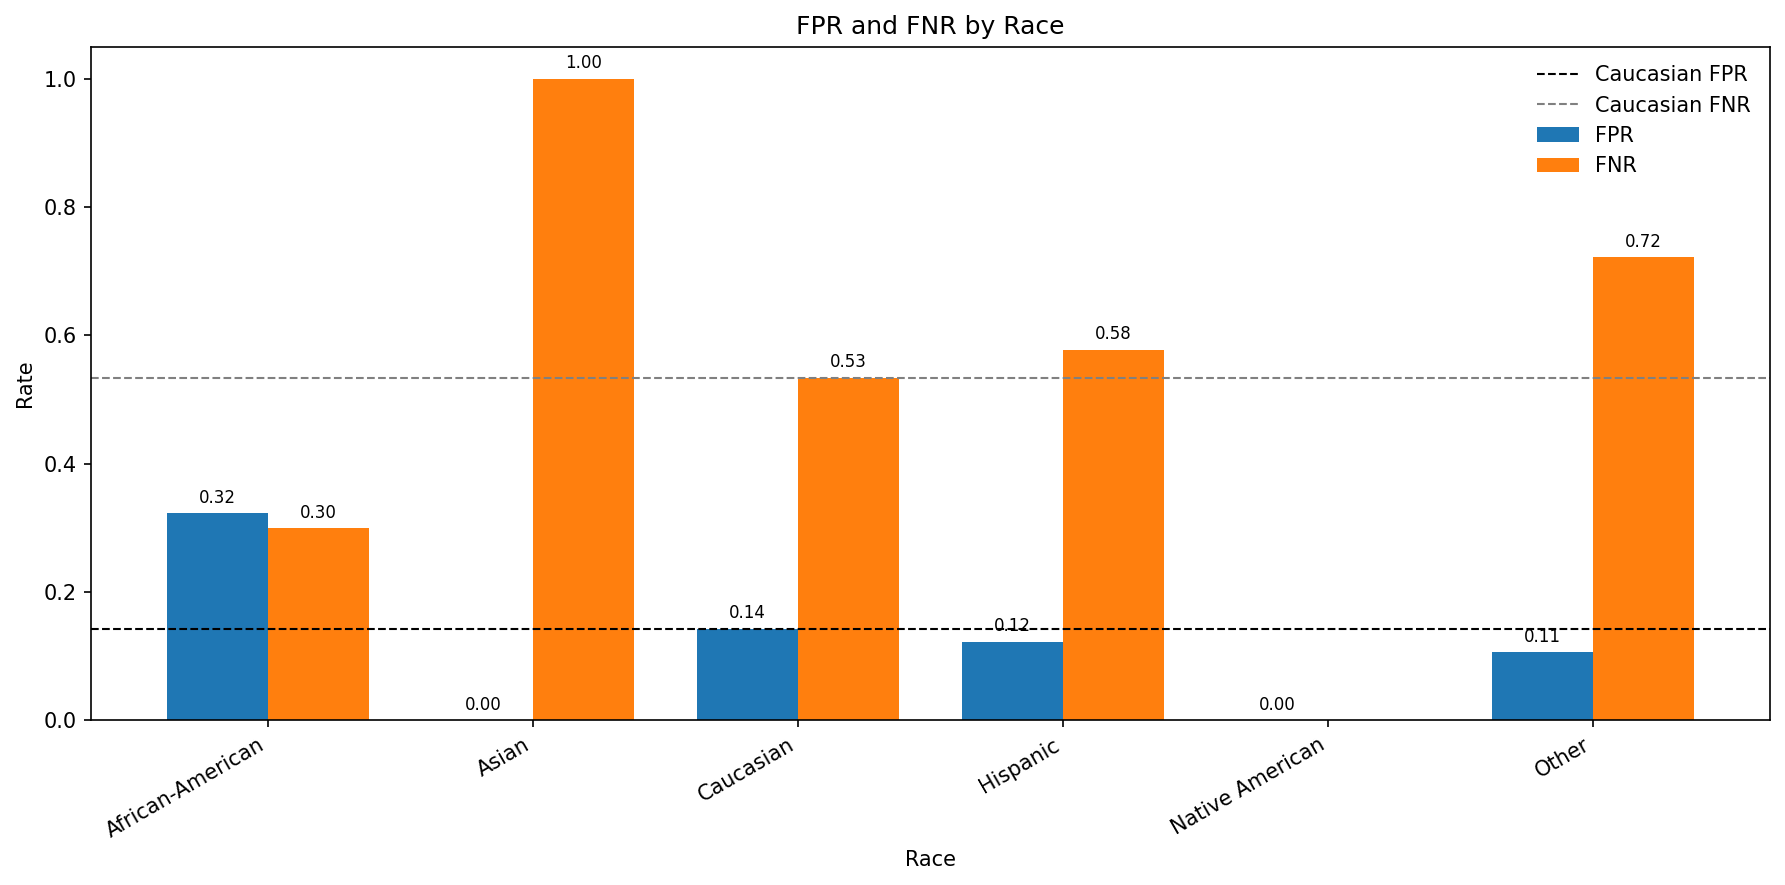

In [49]:
plot_df = error_rates_by_race.sort_values("race").copy()

x = np.arange(len(plot_df))
width = 0.38

cauc_fpr = plot_df.loc[plot_df["race"] == "Caucasian", "FPR"].iloc[0]
cauc_fnr = plot_df.loc[plot_df["race"] == "Caucasian", "FNR"].iloc[0]

fig, ax = plt.subplots(figsize=(12, 6), dpi=150)

bars1 = ax.bar(x - width/2, plot_df["FPR"], width, label="FPR")
bars2 = ax.bar(x + width/2, plot_df["FNR"], width, label="FNR")

ax.axhline(cauc_fpr, color="black", linestyle="--", linewidth=1, label="Caucasian FPR")
ax.axhline(cauc_fnr, color="gray", linestyle="--", linewidth=1, label="Caucasian FNR")

ax.set_title("FPR and FNR by Race")
ax.set_xlabel("Race")
ax.set_ylabel("Rate")
ax.set_xticks(x)
ax.set_xticklabels(plot_df["race"], rotation=30, ha="right")
ax.legend(frameon=False)

for bars in [bars1, bars2]:
    for bar in bars:
        h = bar.get_height()
        ax.annotate(f"{h:.2f}",
                    xy=(bar.get_x() + bar.get_width()/2, h),
                    xytext=(0, 3),
                    textcoords="offset points",
                    ha="center", va="bottom", fontsize=8)

plt.tight_layout()
plt.show()

### 5. Compliance Memo

To: Fairness and Compliance Review Division
Subject: COMPAS Risk Assessment Fairness Review

Following your request, we conducted a disparate impact review of the COMPAS risk assessment model using the cleaned dataset and the prediction model currently under consideration.

The review applied three standard measures of selection disparity: Adverse Impact Ratio (AIR), Marginal Effect (ME), and Standardized Mean Difference (SMD). AIR was evaluated under the EEOC 80% rule, which treats values below 0.80 as evidence of potential adverse impact requiring further review.

The strongest evidence of disparity was observed by race. African-American defendants had an AIR of 0.651 relative to Caucasian defendants, below the 0.80 threshold. At the intersection of race and sex, African-American males were the most adversely affected subgroup, with an AIR of 0.569 relative to Caucasian males. By contrast, female defendants had an AIR of 1.381 relative to male defendants, indicating no evidence of adverse impact by sex alone.

We also evaluated model error rates because unequal error burdens may create regulatory concern even when overall calibration is acceptable. African-American defendants experienced a false positive rate of 0.322, compared with 0.143 for Caucasian defendants. This difference was statistically significant under a two-proportion z-test (z = 5.02, p < 0.001). In practical terms, African-American defendants were substantially more likely to be incorrectly classified as high risk. Caucasian defendants, however, had a higher false negative rate (0.534 versus 0.300), meaning they were more likely to be incorrectly classified as low risk.

Based on these findings, the current model would likely raise compliance concerns under disparate impact standards. We recommend additional review before operational use, including threshold adjustment, subgroup monitoring, and documentation of any business necessity for maintaining the current model design.

The results should be interpreted with caution because several racial subgroups had very small sample sizes, and the model may reflect historical bias present in the underlying data.
